# Process and Explore some ALBATROS Direct Spectra

For some reason during the `202407` season `MARS3` appears to have significantly cleaner data. Let's start our exploration there.

In [1]:
from __future__ import annotations

import pickle as pkl
import warnings
from datetime import timedelta
from pathlib import Path
from typing import Iterable

import cmasher as cmr
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap as LSC
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm.notebook import tqdm

from specscout.core import freq_axis_from_attrs
from specscout.dataset import SpecscoutDataset
from specscout.outlier import QuietSelector, RollingPCABackground
from specscout.patches import open_cube, read_time_range
from specscout.preprocess import PreprocessPipeline, step_safe_db, step_stokes_i, step_stokes_iquv
from specscout.roi import find_rois_from_scores, rois_to_dataframe
from specscout.rolling import RollingPCARunner, padded_utc_range
from specscout.viz.static import (
    plot_roi_event,
    plot_scores_with_rois,
    plot_time_range,
    plot_time_range_stokes_fractional,
)

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.03, 0.9, 256)))
plt.rcParams.update({"font.family": "serif"})

In [2]:
zarr_path = "/Volumes/specscout/zarr/202407/MARS3_202407.zarr/"

analysis_start_utc = "20240720_000000"
analysis_stop_utc = "20241020_000000"

window_seconds = 20 * 60
step_seconds = 5 * 60

chan = (0, 1)

context_hours = 24
stride_hours = 1
score_hours = 1
gap_hours = 0

quiet_fraction = 0.3

k_fit = 128  # modes to fit
k_pca = 16  # modes used for reconstruct in scoring

score_kwargs = dict(method="p99", min_finite_frac=0.7)

ds_start_utc, ds_stop_utc = padded_utc_range(
    analysis_start_utc=analysis_start_utc,
    analysis_stop_utc=analysis_stop_utc,
    context_hours=context_hours,
)

pipe_stokes_i_db = (
    PreprocessPipeline(input_space="linear")
    .with_metadata(
        zarr_path=zarr_path,
        notes="Stokes I from chan 0/1, then safe_db",
    )
    .add(step_stokes_i(name="stokes_i"))
    .add(step_safe_db(name="safe_db"))
)

ds = SpecscoutDataset(
    zarr_path,
    start_utc=ds_start_utc,
    stop_utc=ds_stop_utc,
    window_seconds=window_seconds,
    step_seconds=step_seconds,
    chans=chan,
    pipe=pipe_stokes_i_db,
    return_meta=True,
)

print("Dataset padded range:", ds_start_utc, "->", ds_stop_utc)
print("n_frames:", len(ds))
print(pipe_stokes_i_db.summary())

example_x, example_meta = ds[0]
T, F = example_x.shape
rfi_mask = np.ones((F,), dtype=bool)
rfi_mask[116:384] = False

print("Frame shape:", example_x.shape, "mask shape:", rfi_mask.shape)

qs = QuietSelector(
    method="p99",
    quiet_fraction=quiet_fraction,
    freq_mask=rfi_mask,
)

bg = RollingPCABackground(
    k=k_fit,
    center=True,
    # freq_mask=rfi_mask,
    use_randomized=True,
    n_iter=2,
    random_state=42,
)

runner = RollingPCARunner(
    ds=ds,
    quiet_selector=qs,
    background=bg,
    context_hours=context_hours,
    stride_hours=stride_hours,
    score_hours=score_hours,
    gap_hours=gap_hours,
    k_pca=k_pca,
    score_kwargs=score_kwargs,
    store_masked=True,
)

Dataset padded range: 20240719_120000 -> 20241020_120000
n_frames: 25049
########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   db
input_channels: None
output_channels:('stokes_I',)

metadata: {'zarr_path': '/Volumes/specscout/zarr/202407/MARS3_202407.zarr/', 'notes': 'Stokes I from chan 0/1, then safe_db'}
n_steps: 2
[0] stokes_i in_space=linear out_space=linear in_channels=['pol00', 'pol11'] out_channels=['stokes_I'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11'], 'channel_order_out': ['stokes_I'], 'convention': 'stokes_I = 0.5 * (pol00 + pol11)'}
[1] safe_db in_space=linear out_space=db in_channels=? out_channels=? config={'floor': 1e-12, 'dtype': 'float32'}
Frame shape: (186, 2048) mask shape: (2048,)


In [ ]:
times: list[pd.Timestamp] = []
frame_idx: list[int] = []
scores: list[float] = []

total = runner.n_steps(analysis_start_utc, analysis_stop_utc)

for res in tqdm(
    runner.run(
        analysis_start_utc=analysis_start_utc,
        analysis_stop_utc=analysis_stop_utc,
    ),
    total=total,
    colour="seagreen",
    desc="Rolling PCA",
):
    for score, meta in zip(res.scores, res.metas):
        times.append(pd.Timestamp(meta.start_time_utc))
        frame_idx.append(int(meta.frame_idx))
        scores.append(float(score))

df_scores = (
    pd.DataFrame(
        {
            "time": times,
            "frame_idx": frame_idx,
            "score": scores,
        }
    )
    .sort_values("time")
    .reset_index(drop=True)
)


df_scores.to_pickle("processing/MARS3/MARS3_20240720_20241020_scores.pkl")

In [3]:
with open("processing/MARS3/MARS3_20240720_20241020_scores.pkl", "rb") as f:
    df_scores = pkl.load(f)

df_scores.head()

,time,frame_idx,score
0,2024-07-20 00:01:40.407011+00:00,143,0.268438
1,2024-07-20 00:06:43.202205+00:00,144,0.231850
2,2024-07-20 00:11:45.997400+00:00,145,0.150454
3,2024-07-20 00:16:48.792594+00:00,146,0.114408
4,2024-07-20 00:21:51.587788+00:00,147,0.078865


In [4]:
threshold, rois = find_rois_from_scores(
    df_scores,
    nsig=1,
    pad=timedelta(minutes=5),
    merge_gap=timedelta(minutes=20),
)
df_rois = rois_to_dataframe(rois)
df_rois.head()

,start,stop,peak_score,sum_score,n_frames
0,2024-07-20 14:09:32.794859+00:00,2024-07-20 14:44:46.770831+00:00,3.832895,19.571754,6
1,2024-07-20 16:45:59.445884+00:00,2024-07-20 17:06:05.036273+00:00,2.846093,7.584089,3
2,2024-07-21 01:30:50.146099+00:00,2024-07-21 01:55:58.531682+00:00,11.271885,44.414712,4
3,2024-07-21 04:37:33.568290+00:00,2024-07-21 05:38:01.520234+00:00,3.729802,25.705314,9
4,2024-07-21 12:31:56.316561+00:00,2024-07-21 16:29:02.100307+00:00,9.047463,147.182435,38


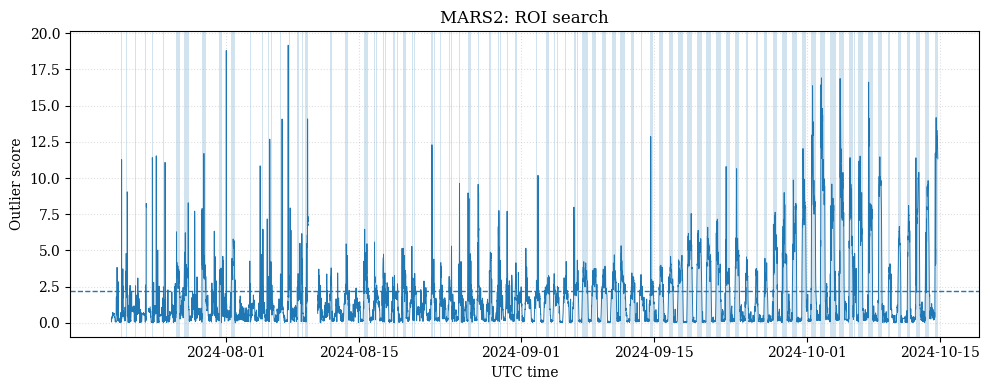

In [5]:
%matplotlib inline

fig, _ax = plot_scores_with_rois(
    df_scores,
    rois,
    threshold=threshold,
    title=("MARS2: ROI search"),
)
plt.tight_layout()
plt.show()

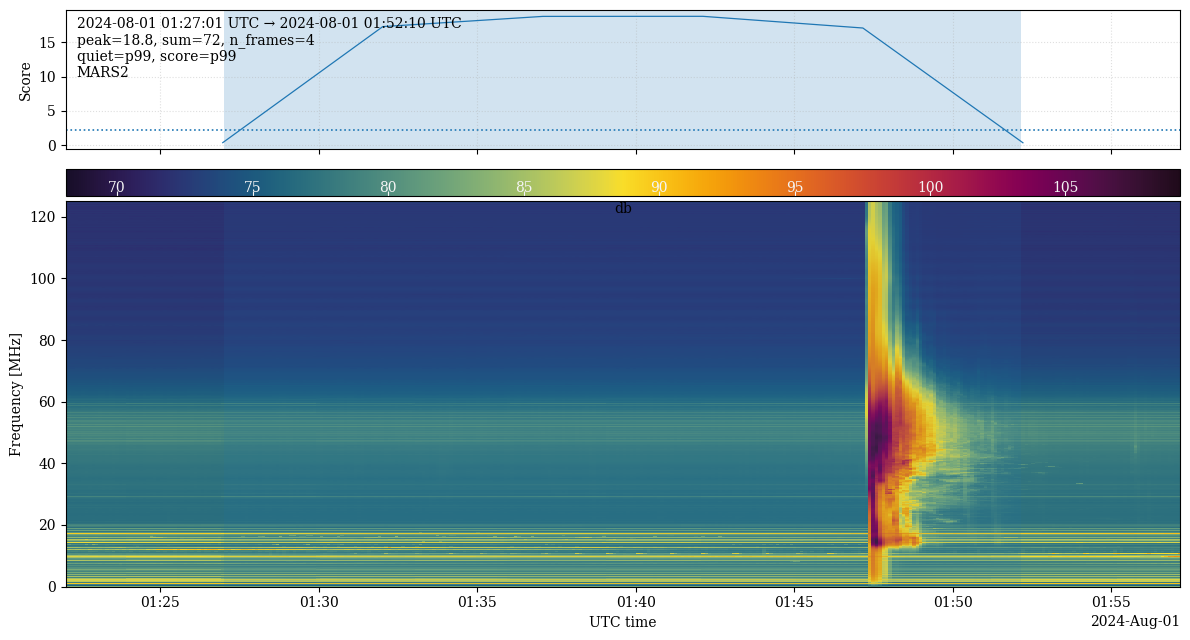

In [6]:
%matplotlib inline

fig, _axs = plot_roi_event(
    station="MARS2",
    roi=rois[36],
    df_scores=df_scores,
    zarr_path=zarr_path,
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    plot_pad_minutes=5,
    threshold=threshold,
    quiet_label="p99",
    score_label="p99",
)

In [7]:
out_dir = Path("processing/MARS3/roi_raw")
out_dir.mkdir(parents=True, exist_ok=True)

for i, roi in enumerate(rois):
    fig, _axs = plot_roi_event(
        station="MARS3",
        roi=roi,
        df_scores=df_scores,
        zarr_path=zarr_path,
        chans=(0, 1),
        pipe=pipe_stokes_i_db,
        plot_pad_minutes=5,
        threshold=threshold,
        quiet_label="p99",
        score_label="p99",
    )

    roi_tag = pd.to_datetime(roi.start, utc=True).strftime("%Y%m%d_%H%M%S")
    fig.savefig(
        f"{out_dir}/roi_{i:04d}.png",
        dpi=144,
        bbox_inches="tight",
    )
    plt.close(fig)

### Eyeball things and find the best events

In [8]:
golden_set = np.array(
    [
        2,
        10,
        12,
        16,
        23,
        24,
        25,
        27,
        28,
        29,
        30,
        31,
        36,
        41,
        44,
        45,
        47,
        53,
        54,
        55,
        61,
        71,
        72,
        95,
        101,
        102,
        104,
        135,
        150,
        188,
    ]
)

print(f"Golden Set: [{golden_set.size}]")

Golden Set: [30]


In [9]:
out_dir = Path("processing/MARS3/golden_set")
out_dir.mkdir(parents=True, exist_ok=True)


for i in golden_set:
    roi = rois[i]
    fig, _axs = plot_roi_event(
        station="MARS3",
        roi=roi,
        df_scores=df_scores,
        zarr_path=zarr_path,
        chans=(0, 1),
        pipe=pipe_stokes_i_db,
        plot_pad_minutes=20,
        threshold=threshold,
        quiet_label="p99",
        score_label="p99",
    )

    roi_tag = pd.to_datetime(roi.start, utc=True).strftime("%Y%m%d_%H%M%S")
    fig.savefig(
        f"{out_dir}/roi_{i:04d}.png",
        dpi=144,
        bbox_inches="tight",
    )
    plt.close(fig)

In [10]:
golden_times = np.array(
    [
        ["20240721_014500", "20240721_020500"],
        ["20240724_072500", "20240724_080500"],
        ["20240724_170500", "20240724_174500"],
        ["20240725_152500", "20240725_155500"],
        ["20240727_180500", "20240727_184500"],
        ["20240727_191500", "20240727_194500"],
        ["20240728_013500", "20240728_022500"],
        ["20240728_180500", "20240728_182500"],
        ["20240729_171500", "20240729_180500"],
        ["20240730_132500", "20240730_134500"],
        ["20240730_143000", "20240730_155500"],
        ["20240730_192500", "20240730_194500"],
        ["20240730_211500", "20240730_215500"],
        ["20240801_013500", "20240801_020500"],
        ["20240804_142500", "20240804_152500"],
        ["20240804_220000", "20240804_224000"],
        ["20240805_085000", "20240805_091000"],
        ["20240805_150500", "20240805_160000"],
        ["20240806_221000", "20240806_224000"],
        ["20240807_133000", "20240807_141000"],
        ["20240808_190500", "20240808_194500"],
        ["20240812_011000", "20240812_014000"],
        ["20240812_182500", "20240812_184500"],
        ["20240820_003500", "20240820_005500"],
        ["20240821_194000", "20240821_201000"],
        ["20240821_224000", "20240821_230500"],
        ["20240822_161000", "20240822_163000"],
        ["20240830_120000", "20240830_123000"],
        ["20240902_192500", "20240902_193500"],
        ["20240914_151500", "20240914_155500"],
    ]
)

## GOES X-Ray Flux

- [goes-r-extreme-ultraviolet-xray-irradiance](https://www.ncei.noaa.gov/products/goes-r-extreme-ultraviolet-xray-irradiance)
- [space-weather-portal](https://lasp.colorado.edu/space-weather-portal)
- [GOES_XRS_readme.pdf](https://www.ngdc.noaa.gov/stp/satellite/goes/doc/GOES_XRS_readme.pdf)
- [GOES-R_EXIS_XRS_L1b_Data_ReadMe.pdf](https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes16/l1b/docs/GOES-R_EXIS_XRS_L1b_Data_ReadMe.pdf)
- [latis-swp-notebook.ipynb](https://github.com/lasp/latis-notebooks/blob/main/latis-swp-notebook.ipynb)

In [11]:
# Leap seconds effective from these UTC instants.
# For example, the leap second inserted on 2016-12-31 becomes effective at
# 2017-01-01 00:00:00 UTC.
_LEAP_SECOND_EFFECTIVE_UTC = pd.DatetimeIndex(
    [
        "2006-01-01T00:00:00Z",  # after 2005-12-31 leap second
        "2009-01-01T00:00:00Z",  # after 2008-12-31
        "2012-07-01T00:00:00Z",  # after 2012-06-30
        "2015-07-01T00:00:00Z",  # after 2015-06-30
        "2017-01-01T00:00:00Z",  # after 2016-12-31
    ],
    tz="UTC",
)


def _count_leap_seconds_since_base(naive_times_utc: pd.DatetimeIndex) -> np.ndarray:
    """
    Count leap seconds since 2000-01-01 12:00:00 UTC for each timestamp.

    Parameters
    ----------
    naive_times_utc
        Timestamps formed from base_time + elapsed_seconds, before leap-second
        correction.

    Returns
    -------
    numpy.ndarray
        Integer leap-second counts, one per timestamp.
    """
    t_ns = naive_times_utc.view("i8")
    leap_ns = _LEAP_SECOND_EFFECTIVE_UTC.view("i8")
    return np.searchsorted(leap_ns, t_ns, side="right").astype(np.int64)


def _iter_days(start: pd.Timestamp, stop: pd.Timestamp) -> Iterable[pd.Timestamp]:
    """Yield UTC dates touched by [start, stop)."""
    day0 = start.floor("D")
    day1 = stop.floor("D")
    for day in pd.date_range(day0, day1, freq="D", tz="UTC"):
        yield day


def _goes_files_for_range(root: str | Path, *, start: str | pd.Timestamp, stop: str | pd.Timestamp) -> list[Path]:
    """
    Return local GOES XRS files overlapping the requested UTC range.

    Expects files named:
        root/YYYY/sci_xrsf-l2-flx1s_g18_dYYYYMMDD_v2-2-1.nc
    """
    root = Path(root)

    start_ts = pd.Timestamp(start, tz="UTC") if not isinstance(start, pd.Timestamp) else start.tz_convert("UTC")
    stop_ts = pd.Timestamp(stop, tz="UTC") if not isinstance(stop, pd.Timestamp) else stop.tz_convert("UTC")

    if not (start_ts < stop_ts):
        raise ValueError("start must be earlier than stop.")

    files: list[Path] = []
    for day in _iter_days(start_ts, stop_ts):
        year_dir = root / f"{day.year:04d}"
        pattern = f"sci_xrsf-l2-flx1s_g18_d{day.strftime('%Y%m%d')}_v*.nc"
        files.extend(sorted(year_dir.glob(pattern)))

    return sorted(files)


def _decode_goes_time_seconds(time_seconds: np.ndarray) -> pd.DatetimeIndex:
    """
    Decode GOES XRS time to UTC, including leap-second correction.

    The raw variable is seconds since 2000-01-01 12:00:00 UTC, computed without
    leap seconds. We first form naive UTC-like timestamps, then add the number
    of leap seconds that have occurred since the base time.
    """
    base = pd.Timestamp("2000-01-01T12:00:00Z")
    naive = pd.to_datetime(time_seconds, unit="s", origin=base.tz_localize(None), utc=True)
    n_leaps = _count_leap_seconds_since_base(naive)
    corrected = naive + pd.to_timedelta(n_leaps, unit="s")
    return pd.DatetimeIndex(corrected, name="time")


def load_goes18_xrs_1s(
    root: str | Path,
    *,
    start: str | pd.Timestamp,
    stop: str | pd.Timestamp,
    short_var: str = "xrsa_flux",
    long_var: str = "xrsb_flux",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load local GOES-18 XRS 1 s data for a UTC interval.

    Parameters
    ----------
    root
        Root directory containing files organized as:
            root/YYYY/sci_xrsf-l2-flx1s_g18_dYYYYMMDD_v*.nc
    start, stop
        UTC bounds. `stop` is treated as exclusive.
    short_var
        Variable name for the short XRS channel.
    long_var
        Variable name for the long XRS channel.

    Returns
    -------
    times, short_xrs, long_xrs
        Arrays ready for direct comparison with ALBATROS:
        - times: numpy datetime64[ns] array (UTC)
        - short_xrs: short-channel flux
        - long_xrs: long-channel flux
    """
    start_ts = pd.Timestamp(start, tz="UTC") if not isinstance(start, pd.Timestamp) else start.tz_convert("UTC")
    stop_ts = pd.Timestamp(stop, tz="UTC") if not isinstance(stop, pd.Timestamp) else stop.tz_convert("UTC")

    files = _goes_files_for_range(root, start=start_ts, stop=stop_ts)
    if not files:
        raise FileNotFoundError(f"No GOES-18 XRS files found under {root!r} for {start_ts} to {stop_ts}.")

    times_all: list[pd.DatetimeIndex] = []
    short_all: list[np.ndarray] = []
    long_all: list[np.ndarray] = []

    for path in files:
        with xr.open_dataset(path, decode_times=False) as ds:
            if "time" not in ds.variables:
                raise KeyError(f"{path.name} is missing variable 'time'.")
            if short_var not in ds.variables:
                raise KeyError(f"{path.name} is missing variable {short_var!r}.")
            if long_var not in ds.variables:
                raise KeyError(f"{path.name} is missing variable {long_var!r}.")

            t = _decode_goes_time_seconds(ds["time"].values)
            times_all.append(t)
            short_all.append(np.asarray(ds[short_var].values))
            long_all.append(np.asarray(ds[long_var].values))

    times = pd.DatetimeIndex(np.concatenate([t.values for t in times_all]), tz="UTC")
    short_xrs = np.concatenate(short_all)
    long_xrs = np.concatenate(long_all)

    order = np.argsort(times.view("i8"))
    times = times[order]
    short_xrs = short_xrs[order]
    long_xrs = long_xrs[order]

    keep = (times >= start_ts) & (times < stop_ts)
    times = times[keep]
    short_xrs = short_xrs[keep]
    long_xrs = long_xrs[keep]

    return times.to_numpy(), short_xrs, long_xrs

In [12]:
times, short_xrs, long_xrs = load_goes18_xrs_1s(
    "/Volumes/specscout/goes18_xrs_1s",
    start="2024-07-01T00:00:00Z",
    stop="2024-07-03T00:00:00Z",
)

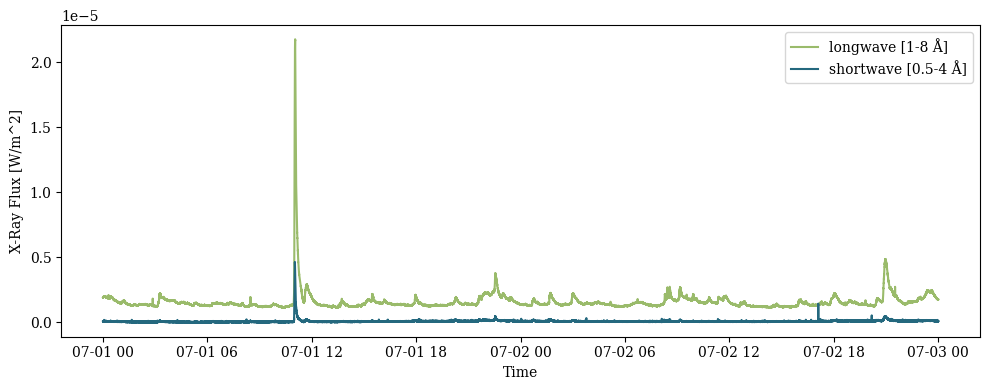

In [13]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(times, long_xrs, color=cmr.pride(0.4), label="longwave [1-8 Å]")
ax.plot(times, short_xrs, color=cmr.pride(0.2), label="shortwave [0.5-4 Å]")

ax.set_xlabel("Time")
ax.set_ylabel("X-Ray Flux [W/m^2]")

plt.legend()

plt.tight_layout()
plt.show()

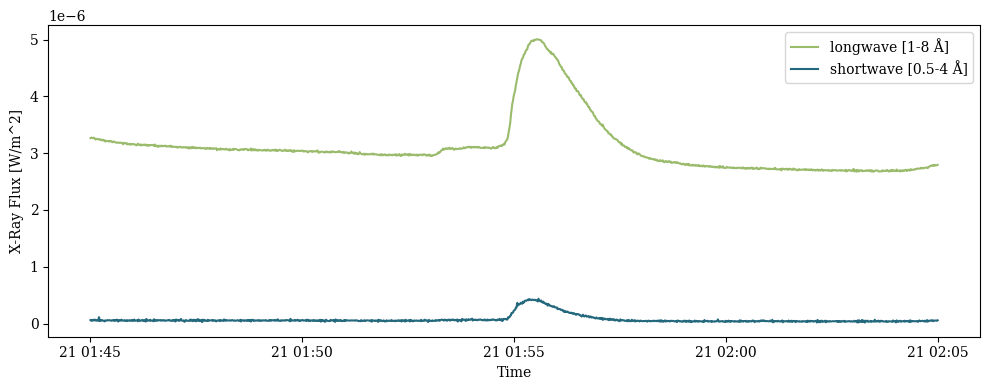

In [14]:
times, short_xrs, long_xrs = load_goes18_xrs_1s(
    "/Volumes/specscout/goes18_xrs_1s",
    start="2024-07-21T01:45:00Z",
    stop="2024-07-21T02:05:00Z",
)

%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(times, long_xrs, color=cmr.pride(0.4), label="longwave [1-8 Å]")
ax.plot(times, short_xrs, color=cmr.pride(0.2), label="shortwave [0.5-4 Å]")

ax.set_xlabel("Time")
ax.set_ylabel("X-Ray Flux [W/m^2]")

plt.legend()

plt.tight_layout()
plt.show()

In [15]:
def _normalize_series(x: np.ndarray) -> np.ndarray:
    """
    Normalize a 1D array to [0, 1], preserving NaNs.
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    finite = np.isfinite(x)
    if not np.any(finite):
        return out

    xmin = np.nanmin(x[finite])
    xmax = np.nanmax(x[finite])

    if np.isclose(xmax, xmin):
        out[finite] = 0.5
        return out

    out[finite] = (x[finite] - xmin) / (xmax - xmin)
    return out


def plot_time_range_with_lightcurves(
    zarr_path: str | Path,
    *,
    start_utc: str | pd.Timestamp,
    stop_utc: str | pd.Timestamp,
    chans: int | tuple[int, ...] | list[int],
    pipe=None,
    goes_root: str | Path | None = None,
    include_goes: bool = True,
    goes_loader=load_goes18_xrs_1s,
    cmap="viridis",
    clim_percentiles: tuple[float, float] = (0.1, 99.9),
    vlims: tuple[float, float] | None = None,
    normalize_lightcurves: bool = True,
    alb_reduce: str = "mean",
    figsize: tuple[float, float] = (12, 7),
    title: str | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plot a specscout time-range waterfall with a light-curve panel above it.

    Top panel
    ---------
    - ALBATROS light curve derived from the plotted waterfall
    - GOES-18 XRS longwave light curve over the same UTC range

    Bottom panel
    ------------
    - Time-frequency waterfall from `read_time_range(...)`

    Parameters
    ----------
    zarr_path
        Path to the specscout Zarr store.
    start_utc, stop_utc
        UTC bounds accepted by `read_time_range(...)`.
    chans
        Raw cube channel selection.
    pipe
        Optional preprocessing pipeline applied after reading.
    goes_root
        Root directory containing local GOES-18 XRS 1 s files, organized as
        `root/YYYY/sci_xrsf-l2-flx1s_g18_dYYYYMMDD_v*.nc`.
    include_goes
        If True, try to load and plot GOES longwave data.
    goes_loader
        Callable with the API of `load_goes18_xrs_1s(...)`.
    cmap
        Colormap for the waterfall.
    clim_percentiles
        Percentiles used for dynamic waterfall scaling when `vlims` is None.
    vlims
        Optional fixed color limits for the waterfall.
    normalize_lightcurves
        If True, normalize ALBATROS and GOES curves independently to [0, 1].
    alb_reduce
        Frequency reduction used to form the ALBATROS light curve.
        Supported values are `"mean"`, `"median"`, and `"sum"`.
    figsize
        Figure size in inches.
    title
        Optional figure title.

    Returns
    -------
    fig, axs
        Matplotlib figure and array of axes `[ax_top, ax_bottom]`.
    """
    data_tf, times, _meta = read_time_range(
        zarr_path,
        start_utc=start_utc,
        stop_utc=stop_utc,
        chans=chans,
        pipe=pipe,
    )

    times = pd.to_datetime(times, utc=True)

    fig, axs = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [1, 4]},
    )
    ax_top, ax_bot = axs

    if data_tf.size == 0 or len(times) == 0:
        ax_top.text(0.5, 0.5, "No data in requested time range", ha="center", va="center")
        ax_top.set_axis_off()
        ax_bot.set_axis_off()
        return fig, axs

    data_tf = np.asarray(data_tf)
    if data_tf.ndim != 2:
        raise ValueError(f"Expected plotted data with shape (T, F) after pipe application, got {data_tf.shape}.")

    if len(times) < 2:
        raise ValueError("Need at least 2 time samples to build a waterfall plot.")

    # ------------------------------------------------------------------
    # ALBATROS light curve from the plotted waterfall
    # ------------------------------------------------------------------
    if alb_reduce == "mean":
        alb_lc = np.nanmean(data_tf, axis=1)
    elif alb_reduce == "median":
        alb_lc = np.nanmedian(data_tf, axis=1)
    elif alb_reduce == "sum":
        alb_lc = np.nansum(data_tf, axis=1)
    else:
        raise ValueError("alb_reduce must be one of {'mean', 'median', 'sum'}.")

    # ------------------------------------------------------------------
    # GOES longwave light curve for the same interval
    # ------------------------------------------------------------------
    goes_times: pd.DatetimeIndex | None = None
    goes_long: np.ndarray | None = None

    if include_goes:
        if goes_root is None:
            raise ValueError("goes_root must be provided when include_goes=True.")

        try:
            # Small +1 s pad on stop because the GOES loader uses an exclusive bound.
            t_goes, _short_goes, long_goes = goes_loader(
                goes_root,
                start=times[0],
                stop=times[-1] + pd.Timedelta(seconds=1),
            )
            goes_times = pd.to_datetime(t_goes, utc=True)
            goes_long = np.asarray(long_goes, dtype=float)

            # Final explicit clip to plotted interval
            keep_goes = (goes_times >= times[0]) & (goes_times <= times[-1])
            goes_times = goes_times[keep_goes]
            goes_long = goes_long[keep_goes]

            if len(goes_times) == 0:
                goes_times = None
                goes_long = None

        except FileNotFoundError:
            warnings.warn(
                "No GOES-18 XRS files found for the requested interval; plotting ALBATROS only.",
                RuntimeWarning,
                stacklevel=2,
            )
        except Exception as exc:
            warnings.warn(
                f"Failed to load GOES-18 XRS data ({exc}); plotting ALBATROS only.",
                RuntimeWarning,
                stacklevel=2,
            )

    # ------------------------------------------------------------------
    # Normalize light curves if desired
    # ------------------------------------------------------------------
    if normalize_lightcurves:
        alb_plot = _normalize_series(alb_lc)
        goes_plot = _normalize_series(goes_long) if goes_long is not None else None
        top_ylabel = "Normalized amplitude"
    else:
        alb_plot = alb_lc
        goes_plot = goes_long
        top_ylabel = "Amplitude"

    # ------------------------------------------------------------------
    # Top panel: light curves
    # ------------------------------------------------------------------
    ax_top.plot(times, alb_plot, lw=1.2, label="ALBATROS   [ 1-125 MHz ]", drawstyle="steps-mid", color="k")
    if goes_times is not None and goes_plot is not None:
        ax_top.plot(goes_times, goes_plot, lw=1.2, label="GOES X-Ray [ 1-8 Å ]", drawstyle="steps-mid", color="k", ls="--")

    # ax_top.set_ylabel(top_ylabel)
    ax_top.grid(ls=":", alpha=0.4)
    ax_top.legend(loc="upper right", fontsize=8)

    # ------------------------------------------------------------------
    # Bottom panel: waterfall
    # ------------------------------------------------------------------
    cube, attrs, _time_axis = open_cube(zarr_path)
    freqs_all, _x_label = freq_axis_from_attrs(attrs, cube.shape[1])
    freqs = np.asarray(freqs_all[: data_tf.shape[1]], dtype=float)

    t_num = mdates.date2num(times.to_pydatetime())
    dt_days = np.median(np.diff(t_num))
    x_edges = np.concatenate(
        [
            [t_num[0] - 0.5 * dt_days],
            0.5 * (t_num[:-1] + t_num[1:]),
            [t_num[-1] + 0.5 * dt_days],
        ]
    )

    y_edges = np.concatenate(
        [
            [freqs[0] - 0.5 * (freqs[1] - freqs[0])],
            0.5 * (freqs[:-1] + freqs[1:]),
            [freqs[-1] + 0.5 * (freqs[-1] - freqs[-2])],
        ]
    )

    mesh = ax_bot.pcolormesh(
        x_edges,
        y_edges,
        data_tf.T,
        shading="auto",
        cmap=cmap,
    )

    if vlims is not None:
        mesh.set_clim(*vlims)
    else:
        vmin = float(np.nanpercentile(data_tf, clim_percentiles[0]))
        vmax = float(np.nanpercentile(data_tf, clim_percentiles[1]))
        mesh.set_clim(vmin, vmax)

    ax_bot.set_ylabel("Frequency [MHz]")
    ax_bot.set_xlabel("UTC time")

    divider = make_axes_locatable(ax_bot)
    cax = divider.append_axes("top", size="7%", pad=0.07)
    cbar = fig.colorbar(mesh, cax=cax, orientation="horizontal")
    cbar.ax.xaxis.set_ticks_position("bottom")
    cbar.ax.xaxis.set_label_position("bottom")
    cbar.ax.tick_params(
        axis="x",
        direction="in",
        pad=-14,
        color="whitesmoke",
        labelcolor="whitesmoke",
    )
    # cbar.set_label("dB", color="whitesmoke", va="bottom")

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax_bot.xaxis.set_major_locator(locator)
    ax_bot.xaxis.set_major_formatter(formatter)

    if title is None:
        title = (
            f"MARS3 Stokes I dB: [ {times[0].strftime('%Y-%m-%d %H:%M')} \u2192 {times[-1].strftime('%Y-%m-%d %H:%M UTC')} ]"
        )
    fig.suptitle(title, y=0.969, ha="right", x=0.532)

    fig.tight_layout()
    return fig, axs

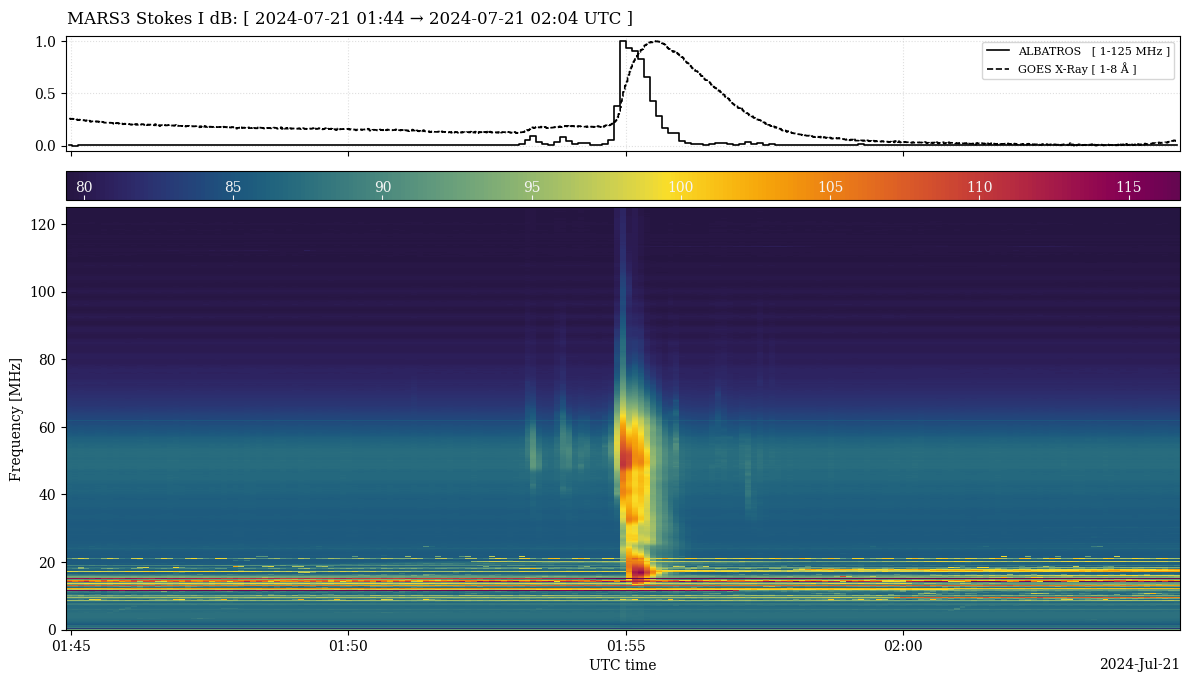

In [16]:
%matplotlib inline
fig, axs = plot_time_range_with_lightcurves(
    zarr_path=zarr_path,
    start_utc=golden_times[0][0],
    stop_utc=golden_times[0][1],
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    goes_root="/Volumes/specscout/goes18_xrs_1s/",
    cmap=prd,
    clim_percentiles=(0.1, 99.9),
    normalize_lightcurves=True,
)

plt.show()

In [ ]:
# out_dir = Path("processing/MARS3/golden_times/stokes_i")
# out_dir.mkdir(parents=True, exist_ok=True)


# for i, gt in enumerate(golden_times):
#     fig, ax = plot_time_range(
#         zarr_path=zarr_path,
#         start_utc=gt[0],
#         stop_utc=gt[1],
#         cmap=prd,
#         chans=(0, 1),
#         pipe=pipe_stokes_i_db,
#         clim_percentiles=(0.1, 99.9),
#     )
#     plt.savefig(f"{out_dir}/MARS3_I_{i}_{gt[0]}_{gt[1]}.png", dpi=300)
#     plt.close()

In [20]:
pipe_stokes_iquv = PreprocessPipeline().add(step_stokes_iquv())
print(pipe_stokes_iquv.summary())

out_dir = Path("processing/MARS3/golden_times/stokes_iquv")
out_dir.mkdir(parents=True, exist_ok=True)

for i, gt in enumerate(golden_times):
    fig, ax = plot_time_range_stokes_fractional(
        zarr_path=zarr_path,
        start_utc=gt[0],
        stop_utc=gt[1],
        chans=(0, 1, 2, 3),
        pipe=pipe_stokes_iquv,
        clim_percentiles=(0.1, 99.9),
    )
    plt.savefig(f"{out_dir}/MARS3_{i}_IQUV_{gt[0]}_{gt[1]}.png", dpi=300)
    plt.close()

########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   linear
input_channels: None
output_channels:('stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V')

n_steps: 1
[0] stokes_iquv in_space=linear out_space=linear in_channels=['pol00', 'pol11', 'pol01_mag', 'pol01_phase'] out_channels=['stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11', 'pol01_mag', 'pol01_phase'], 'channel_order_out': ['stokes_I', 'stokes_Q', 'stokes_U', 'stokes_V'], 'convention': {'stokes_I': '0.5 * (pol00 + pol11)', 'stokes_Q': '0.5 * (pol00 - pol11)', 'stokes_U': 'real(pol01_mag * exp(1j * pol01_phase))', 'stokes_V': 'imag(pol01_mag * exp(1j * pol01_phase))'}}


In [21]:
out_dir = Path("processing/MARS3/golden_times/stokes_i")
out_dir.mkdir(parents=True, exist_ok=True)

for i, gt in enumerate(golden_times):
    fig, axs = plot_time_range_with_lightcurves(
        zarr_path=zarr_path,
        start_utc=gt[0],
        stop_utc=gt[1],
        chans=(0, 1),
        pipe=pipe_stokes_i_db,
        goes_root="/Volumes/specscout/goes18_xrs_1s/",
        cmap=prd,
        clim_percentiles=(0.1, 99.9),
        normalize_lightcurves=True,
    )
    fig.savefig(
        f"{out_dir}/MARS3_I_GOES_{i}_{gt[0]}_{gt[1]}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close(fig)

/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_4935/90093170.py:127: RuntimeWarning: Mean of empty slice
  alb_lc = np.nanmean(data_tf, axis=1)
/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_4935/90093170.py:127: RuntimeWarning: Mean of empty slice
  alb_lc = np.nanmean(data_tf, axis=1)
/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_4935/90093170.py:127: RuntimeWarning: Mean of empty slice
  alb_lc = np.nanmean(data_tf, axis=1)
/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_4935/90093170.py:127: RuntimeWarning: Mean of empty slice
  alb_lc = np.nanmean(data_tf, axis=1)
/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_4935/90093170.py:127: RuntimeWarning: Mean of empty slice
  alb_lc = np.nanmean(data_tf, axis=1)
/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_4935/90093170.py:127: RuntimeWarning: Mean of empty slice
  alb_lc = np.nanmean(data_tf, axis=1)
/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_4935/